# P6: Compositional vs positional

This protocol contrasts **compositional** and **positional** CPP strategies. Once you have two labelled sets of sequences, a **test group** (`label=1`) and a **reference group** (`label=0`), and you want CPP to tell you *what physicochemically distinguishes them*, there is one design choice that quietly governs everything: **how finely should each feature be localized?** A CPP feature is always a `Part-Split-Scale` triple, and it is the **split** that decides whether a scale is averaged over a *whole part* (composition-like, position-agnostic) or over *specific sub-regions / positions* (location-resolved). You never set a `strategy=` switch: the strategy *emerges* from the `split_kws` recipe you hand to `CPP`.

This protocol is a determinant-discovery workflow: we contrast two groups and read out the **signature** of the test group, but here the focus is the *shape* of that signature. We show how to write each recipe deliberately and how the choice maps onto the **prediction level**.

Composition answers **"what"** (how much of a property is present across a part), position answers **"where"** (at which residues the property differs). Compositional CPP = a single whole-part average, `Segment(1,1)`; positional CPP = sub-segments (`n_split_max>1`) plus `Pattern` / `PeriodicPattern`. As a rule of thumb: compositional ~ **protein level** (`SEQ_*`), positional ~ **residue level** (`AA_*`), and **domain level** (`DOM_*`) happily uses both.

**When to use it.** Use this protocol when you already have **two labelled sets of sequences** and need to decide *how finely your CPP features should be localized* before you commit to a signature. The unit of comparison stays fixed by your prediction level: it is only the locality of the split that you are tuning here.

| Question | Strategy | Prediction level |
| --- | --- | --- |
| *"Is one group globally enriched in a property?"* (e.g. whole-chain composition) | **Compositional** | protein level (`SEQ_*`) |
| *"Where along the region does the property differ?"* (e.g. a residue near a cleavage site) | **Positional** | residue level (`AA_*`) |
| *"Both: coarse composition **and** a location-specific signal in a defined sub-region"* | **Both** | domain level (`DOM_*`) |

Compositional features are coarse and robust (few features, composition-like); positional features are fine and mechanistically actionable but more numerous. The strategy should match the biological resolution your question needs.

**When *not* to use it.** If you have not yet built `df_parts` or chosen a prediction level, start with *P1: CPP signature* (and the parts/splits engineering in *P4: Engineer features*) first; this protocol assumes those are settled. It is also not a feature-*selection* step: here we only shape the split grid; trimming the resulting signature down to a compact, non-redundant set is the job of *P7: Select & reduce features* (see **Next step**). And if your question genuinely is global ("is the whole chain enriched?"), do not reach for a dense `Pattern` / `PeriodicPattern` grid; that only inflates the feature count without adding interpretive value.

**Input.** A `df_seq` with one row per protein and a binary `label` column, the **test group** (`label=1`) versus the **reference group** (`label=0`). It comes from an upstream dataset / sampling step (see *P1: CPP signature*).

Here we work at the **domain level** with the bundled **`DOM_GSEC`** gamma-secretase dataset, so the unit of comparison is the transmembrane-domain (TMD) part set, native ground for CPP. With `n=50` we load `2N = 100` rows (50 substrates + 50 non-substrates). Each row carries `entry`, `sequence`, `label`, and the domain-coordinate columns `tmd_start`, `tmd_stop`, `jmd_n`, `tmd`, `jmd_c` that `SequenceFeature.get_df_parts` consumes.

In [1]:
import aaanalysis as aa

aa.options["verbose"] = False
aa.options["random_state"] = 42

# Two labelled sets of sequences (label: 1 = substrate/test, 0 = reference)
# n=50 -> 2N=100 rows (50 substrates + 50 non-substrates)
df_seq = aa.load_dataset(name="DOM_GSEC", n=50)
labels = df_seq["label"].to_list()
aa.display_df(df=df_seq, n_rows=5)

,entry,gene,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,Q14802,FXYD3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0,37,59,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
2,Q86UE4,MTDH,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0,50,72,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
3,Q969W9,PMEPA1,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0,41,63,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
4,P53801,PTTG1IP,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0,97,119,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
5,Q8IUW5,RELL1,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0,59,81,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE


**Run.** The **real** entry point is `CPP(df_parts=..., split_kws=...).run(labels=...)`. `CPP` does **not** take `df_seq` / `labels` directly: you first build sequence *parts* with `SequenceFeature.get_df_parts`, then pass a `split_kws` recipe that encodes the strategy (see the CPP tutorial for the function details). The *only* thing that differs between compositional and positional is `split_kws`; the parts are identical.

In [2]:
# Build sequence parts once, shared by both strategies (TMD / JMD-N / JMD-C + composites)
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
aa.display_df(df=df_parts, n_rows=5)

,tmd,jmd_n_tmd_n,tmd_c_jmd_c
entry,,,
Q14802,LQVGGLICAGVLCAMGIIIVMSA,NSPFYYDWHSLQVGGLICAGVL,CAMGIIIVMSAKCKCKFGQKS
Q86UE4,WVILVGTGALGLLLLFLLGYGWA,LGLEPKRYPGWVILVGTGALGL,LLLFLLGYGWAAACAGARKKR
Q969W9,FVQIIIIVVVMMVMVVVITCLLS,FQSMEITELEFVQIIIIVVVMM,VMVVVITCLLSHYKLSARSFI
P53801,ALIITMSVVGGTLLLGIAICCCC,RWGVCWVNFEALIITMSVVGGT,LLLGIAICCCCCCRRKRSRKP
Q8IUW5,IAYALVPVFFIMGLFGVLICHLL,NDTGNGHPEYIAYALVPVFFIM,GLFGVLICHLLKKKGYRCTTE


In [3]:
# --- Recipe A: COMPOSITIONAL (position-agnostic, whole-part average) ---
# A single Segment(1,1) per part -> the feature is a composition-like mean over the ENTIRE part.
split_kws_comp = sf.get_split_kws(split_types="Segment",
                                  n_split_min=1,
                                  n_split_max=1)
split_kws_comp

{'Segment': {'n_split_min': 1, 'n_split_max': 1}}

In [4]:
cpp = aa.CPP(df_parts=df_parts, split_kws=split_kws_comp)
df_feat_comp = cpp.run(labels=labels, n_filter=20)  # compositional yields fewer candidates than positional
aa.display_df(df=df_feat_comp[["feature", "category", "subcategory", "abs_auc", "mean_dif", "positions"]], n_rows=10)

,feature,category,subcategory,abs_auc,mean_dif,positions
1,"TMD_C_JMD_C-Seg...1,1)-WOLS870103",Others,PC 4,0.393000,-0.079000,"21,22,23,24,25,...,36,37,38,39,40"
2,"TMD_C_JMD_C-Seg...1,1)-ZIMJ680104",Energy,Isoelectric point,0.339000,0.056000,"21,22,23,24,25,...,36,37,38,39,40"
3,"TMD_C_JMD_C-Seg...1,1)-AURR980112",Conformation,α-helix,0.335000,0.069000,"21,22,23,24,25,...,36,37,38,39,40"
4,"TMD_C_JMD_C-Seg...1,1)-WILM950103",Polarity,Hydrophobicity (interface),0.288000,-0.059000,"21,22,23,24,25,...,36,37,38,39,40"
5,"TMD_C_JMD_C-Seg...1,1)-GEOR030108",Structure-Activity,Stability (helix-coil),0.287000,0.076000,"21,22,23,24,25,...,36,37,38,39,40"
6,"TMD_C_JMD_C-Seg...1,1)-CHOP780212",Conformation,β-sheet (C-term),0.282000,-0.067000,"21,22,23,24,25,...,36,37,38,39,40"
7,"TMD_C_JMD_C-Seg...1,1)-JACR890101",Polarity,Hydrophobicity (surrounding),0.281000,-0.057000,"21,22,23,24,25,...,36,37,38,39,40"
8,"TMD_C_JMD_C-Seg...1,1)-JANJ780101",ASA/Volume,Accessible surface area (ASA),0.278000,0.058000,"21,22,23,24,25,...,36,37,38,39,40"
9,"TMD_C_JMD_C-Seg...1,1)-FUKS010109",Composition,AA composition,0.277000,0.061000,"21,22,23,24,25,...,36,37,38,39,40"
10,"JMD_N_TMD_N-Seg...1,1)-KARP850101",Structure-Activity,Flexibility,0.270000,0.057000,"1,2,3,4,5,6,7,8...,16,17,18,19,20"


In [5]:
# --- Recipe B: POSITIONAL (location-resolved sub-regions / positions) ---
# Sub-segments (n_split_max>1) PLUS Pattern and PeriodicPattern -> features resolve to WHERE in the part.
split_kws_pos = sf.get_split_kws(split_types=["Segment", "Pattern", "PeriodicPattern"],
                                 n_split_min=1,
                                 n_split_max=5,
                                 steps_pattern=[3, 4],
                                 steps_periodicpattern=[3, 4])
split_kws_pos

{'Segment': {'n_split_min': 1, 'n_split_max': 5},
 'Pattern': {'steps': [3, 4], 'n_min': 2, 'n_max': 4, 'len_max': 15},
 'PeriodicPattern': {'steps': [3, 4]}}

In [6]:
cpp = aa.CPP(df_parts=df_parts, split_kws=split_kws_pos)
df_feat_pos = cpp.run(labels=labels, n_filter=30)
aa.display_df(df=df_feat_pos[["feature", "category", "subcategory", "abs_auc", "mean_dif", "positions"]], n_rows=10)

,feature,category,subcategory,abs_auc,mean_dif,positions
1,"TMD_C_JMD_C-Seg...2,3)-QIAN880106",Conformation,α-helix,0.387000,0.121000,"27,28,29,30,31,32,33"
2,"TMD_C_JMD_C-Pat...,12)-ROBB760109",Conformation,β-turn (N-term),0.377000,-0.127000,"21,25,28,32"
3,"TMD_C_JMD_C-Seg...4,5)-ZIMJ680104",Energy,Isoelectric point,0.373000,0.220000,"33,34,35,36"
4,"TMD_C_JMD_C-Seg...4,5)-WOLS870103",Others,PC 4,0.370000,-0.218000,"33,34,35,36"
5,"TMD_C_JMD_C-Seg...3,4)-FAUJ880104",Shape,Side chain length,0.366000,0.205000,"31,32,33,34,35"
6,"TMD_C_JMD_C-Seg...2,3)-WOLS870103",Others,PC 4,0.365000,-0.154000,"27,28,29,30,31,32,33"
7,"TMD_C_JMD_C-Seg...4,5)-ONEK900101",Others,Unclassified (Others),0.364000,0.097000,"33,34,35,36"
8,"TMD_C_JMD_C-Seg...4,5)-FINA910103",Conformation,α-helix (C-cap),0.362000,0.264000,"33,34,35,36"
9,"TMD_C_JMD_C-Pat...,15)-QIAN880107",Conformation,α-helix,0.359000,0.158000,"25,28,32,35"
10,"TMD_C_JMD_C-Pat...,15)-MUNV940101",Energy,Free energy (folding),0.358000,-0.097000,"24,28,32,35"


In [7]:
# Rank each signature by tree-based feature importance (needed by feature_map).
# One clearly-named TreeModel per strategy keeps the comp/pos blocks parallel.
tm = aa.TreeModel()
X_comp = sf.feature_matrix(features=df_feat_comp["feature"], df_parts=df_parts)
df_feat_comp = tm.fit(X_comp, labels=labels).add_feat_importance(df_feat=df_feat_comp)

tm = aa.TreeModel()
X_pos = sf.feature_matrix(features=df_feat_pos["feature"], df_parts=df_parts)
df_feat_pos = tm.fit(X_pos, labels=labels).add_feat_importance(df_feat=df_feat_pos)

aa.display_df(df=df_feat_pos[["feature", "subcategory", "mean_dif", "abs_auc", "feat_importance"]], n_rows=6)

,feature,subcategory,mean_dif,abs_auc,feat_importance
1,"TMD_C_JMD_C-Seg...2,3)-QIAN880106",α-helix,0.121000,0.387000,8.225000
2,"TMD_C_JMD_C-Pat...,12)-ROBB760109",β-turn (N-term),-0.127000,0.377000,5.570000
3,"TMD_C_JMD_C-Seg...4,5)-ZIMJ680104",Isoelectric point,0.220000,0.373000,3.317000
4,"TMD_C_JMD_C-Seg...4,5)-WOLS870103",PC 4,-0.218000,0.370000,3.021000
5,"TMD_C_JMD_C-Seg...3,4)-FAUJ880104",Side chain length,0.205000,0.366000,4.483000
6,"TMD_C_JMD_C-Seg...2,3)-WOLS870103",PC 4,-0.154000,0.365000,3.341000


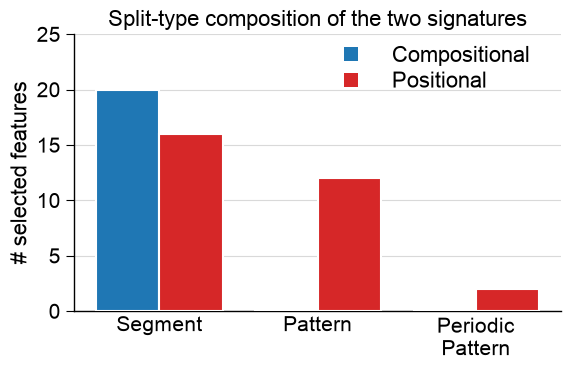

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature id is PART-SPLIT-SCALE; the SPLIT field's head names the split type.
def split_type_counts(df_feat):
    types = df_feat["feature"].str.split("-").str[1].str.split("(").str[0]
    return types.value_counts()

order = ["Segment", "Pattern", "PeriodicPattern"]
counts_comp = split_type_counts(df_feat_comp).reindex(order, fill_value=0)
counts_pos = split_type_counts(df_feat_pos).reindex(order, fill_value=0)

aa.plot_settings(font_scale=0.9, weight_bold=False)
colors = aa.plot_get_clist(n_colors=2)
fig, ax = plt.subplots(figsize=(6, 4))
x = range(len(order))
w = 0.4
ax.bar([i - w / 2 for i in x], counts_comp.values, width=w, label="Compositional",
       color=colors[0], edgecolor="white", zorder=3)
ax.bar([i + w / 2 for i in x], counts_pos.values, width=w, label="Positional",
       color=colors[1], edgecolor="white", zorder=3)
ax.set_xticks(list(x))
ax.set_xticklabels(["Segment", "Pattern", "Periodic\nPattern"])
ax.set_ylabel("# selected features")
ax.set_title("Split-type composition of the two signatures")
ax.set_ylim(0, max(counts_comp.max(), counts_pos.max()) * 1.25)
ax.grid(axis="y", color="0.85", zorder=0)
ax.tick_params(axis="x", length=0)
sns.despine()
aa.plot_legend(dict_color={"Compositional": colors[0], "Positional": colors[1]},
               n_cols=1, x=0.5, y=1.0, marker="s", marker_size=10)
plt.tight_layout()
plt.show()

**Output.** Both strategies return the same `df_feat` **signature** schema (one row per selected feature). Key columns:

- `feature`: the `Part-Split-Scale` id (*where x how x which property*). The **Split** field is what differs: compositional ids carry only `Segment(1,1)`; positional ids carry `Segment(i,n)`, `Pattern(...)`, or `PeriodicPattern(...)`.
- `category` / `subcategory`: the AAontology property group.
- `abs_auc`: effect size / group-separation strength.
- `mean_dif`: mean difference (test minus reference); the **sign** gives the direction.
- `positions`: the residue positions the feature averages over (a single broad span for compositional; tight, specific positions for positional).
- `feat_importance`: tree-based importance used to rank the signature.

The bar plot above makes the strategic difference concrete: the compositional signature is **all `Segment`** (whole-part means), while the positional signature mixes `Segment` sub-regions, `Pattern`, and `PeriodicPattern`. Read the two feature maps below as *rows = properties, columns = positions along the parts, colour = direction x strength*.

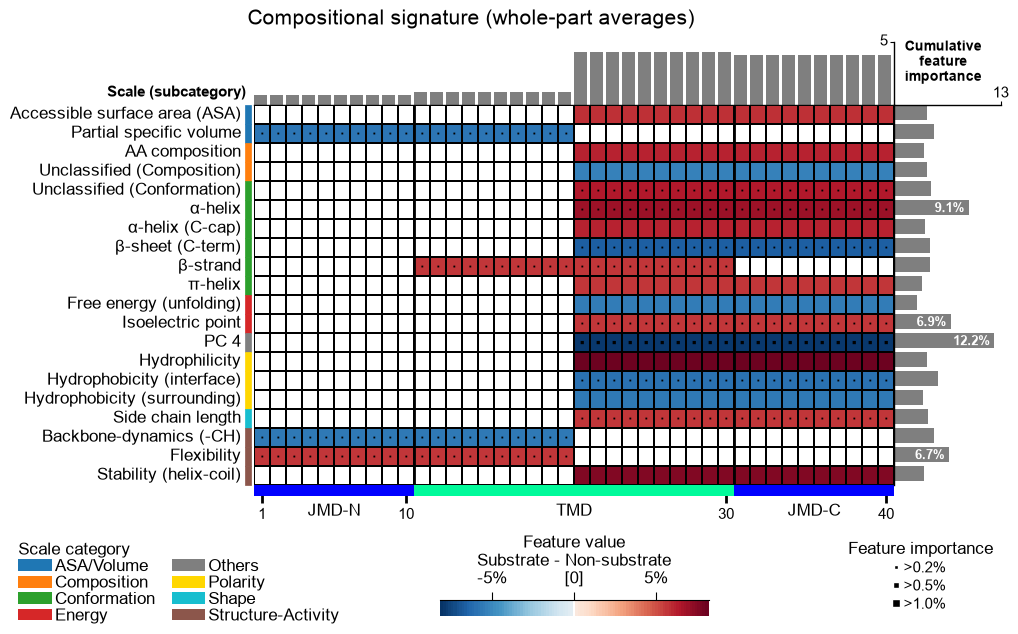

In [9]:
aa.plot_settings(font_scale=0.7, weight_bold=False)
cpp_plot = aa.CPPPlot()
cpp_plot.feature_map(df_feat=df_feat_comp, name_test="Substrate", name_ref="Non-substrate")
plt.gcf().suptitle("Compositional signature (whole-part averages)", y=1.02)
plt.show()

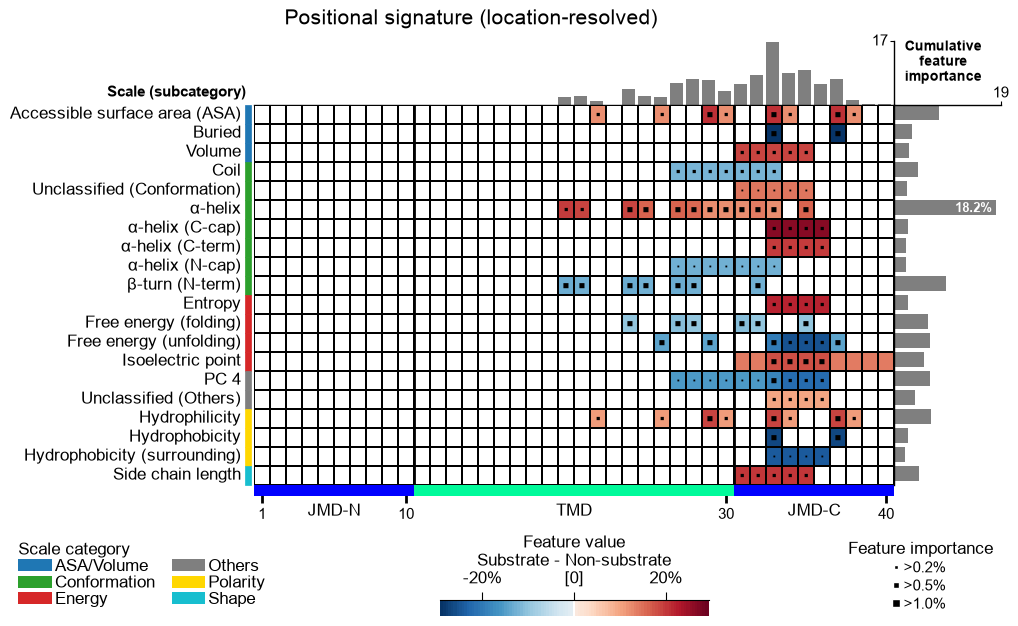

In [10]:
aa.plot_settings(font_scale=0.7, weight_bold=False)
cpp_plot = aa.CPPPlot()
cpp_plot.feature_map(df_feat=df_feat_pos, name_test="Substrate", name_ref="Non-substrate")
plt.gcf().suptitle("Positional signature (location-resolved)", y=1.02)
plt.show()

**How to interpret.** Notice how the biological reading mirrors the strategy you chose. The `Part-` prefix below is schematic: it stands for whichever part actually wins the filter (in this `DOM_GSEC` run that happens to be the composite `TMD_C_JMD_C`, as the displayed `df_feat` shows), so read the ids for their **Split** field, not the literal part name:

| Strategy | Feature id looks like | Biological reading (gamma-secretase example) | Best prediction level |
| --- | --- | --- | --- |
| **Compositional** | `...-Segment(1,1)-...` | *"Substrates are richer in small hydrophobic residues across the whole part."*: coarse, composition-like, robust. | protein level |
| **Positional** | `...-Pattern(...)-...` / `...-Segment(3,5)-...` | *"Substrates differ in a charged-residue propensity at specific positions near the cleavage site (TMD centre)."*: fine, location-specific, mechanistically actionable. | residue level |
| **Both** | mix of the above | domain-level tasks benefit from coarse composition **and** local position signal in one signature. | domain level |

In short: compositional answers *"how much"* (global property level); positional answers *"where"* (location of the discriminating property). For mechanism (pinning a signal to a cleavage-adjacent residue), the positional strategy is the more actionable one.

**Key takeaways**

- The strategy is *not* a parameter; it **emerges from `split_kws`**. `Segment(1,1)` alone is compositional; adding `n_split_max>1` / `Pattern` / `PeriodicPattern` makes it positional.
- Both recipes return the **same `df_feat` signature schema**: only the `Split` field of the `feature` id (and how tight the `positions` span is) tells the two apart.
- Match locality to the question: compositional ~ protein level (the "what"), positional ~ residue level (the "where"), domain level uses both.

**Common mistakes.**

- **Using a positional recipe for a protein-level task.** Whole-chain composition questions only need `Segment(1,1)`; a large `Pattern` / `PeriodicPattern` grid over a long chain explodes the feature count for no interpretive gain.
- **Using a compositional recipe for a residue-level task.** A single whole-part average cannot localize a site-specific signal, you lose exactly the *where* the question is about.
- **Not matching strategy to prediction level.** Remember the mapping: compositional ~ protein, positional ~ residue, domain uses both. There is no `strategy=` parameter; the strategy *emerges* from `split_kws`.
- **Forgetting `feat_importance`.** `CPPPlot.feature_map` is an *instance* method and needs a `feat_importance` column; add it with `TreeModel.add_feat_importance` after `fit` (skipping this raises in `feature_map`).

**Next step.** Both signatures here were capped with a plain `n_filter`, so they may still carry redundant features. To turn a raw signature into a compact, non-redundant feature set (redundancy reduction plus tree-based feature selection), continue with **P7: Select & reduce features**.